# finetune_weighted_rmse — inference & diagnostics
Checkpoint: `results/finetune_weighted_rmse.h5`  
Config: `config_finetune_weighted_rmse.yaml` · sweep K + cosine LR + scale-0 loss + shallow_weight=3

In [1]:
import sys, os

_proj_db = r'C:\Users\marrocol\AppData\Local\miniforge3\envs\mswe-gnn\Lib\site-packages\pyproj\proj_dir\share\proj'
os.environ.setdefault('PROJ_DATA', _proj_db)
os.environ.setdefault('PROJ_LIB',  _proj_db)

try:
    REPO_ROOT = os.path.abspath(os.path.join(os.path.dirname(__vsc_ipynb_file__), '..'))
except NameError:
    REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

import torch
import wandb
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from utils.load import read_config
from utils.miscellaneous import get_model, fix_dict_in_config
from utils.dataset import create_model_dataset, get_temporal_test_dataset_parameters, to_temporal_dataset
from utils.visualization import PlotRollout
from training.train import LightningTrainer

torch.backends.cudnn.deterministic = True
torch.set_float32_matmul_precision('high')
print('Repo root:', REPO_ROOT)

Repo root: c:\Users\marrocol\OneDrive - Stichting Deltares\Documents\mSWE-GNN\mSWE-GNN_marg\mSWE-GNN_marg


## Paths

In [2]:
CHECKPOINT   = os.path.join(REPO_ROOT, 'results', 'finetune_weighted_rmse.h5')
CONFIG       = 'config_finetune_weighted_rmse.yaml'
DATASET_NAME = 'ahr_river_v03_marg_additionalsrc_velocity_100m_warmstart'

print('Checkpoint exists:', os.path.exists(CHECKPOINT))
print('Checkpoint size:  ', f'{os.path.getsize(CHECKPOINT)/1e6:.1f} MB')

Checkpoint exists: True
Checkpoint size:   9.7 MB


## Load config and dataset

In [3]:
cfg = read_config(CONFIG)
cfg['dataset_parameters']['test_dataset_name']  = DATASET_NAME
cfg['dataset_parameters']['train_dataset_name'] = DATASET_NAME
cfg['saved_model'] = CHECKPOINT

wandb.init(mode='disabled', project='mswe-gnn', config=cfg)
fix_dict_in_config(wandb)
config = wandb.config

device = torch.device('cpu')

_, _, test_dataset, scalers = create_model_dataset(
    scalers=config.scalers, device=device,
    **config.dataset_parameters,
    **config.selected_node_features,
    **config.selected_edge_features
)

temporal_test_dataset_parameters = get_temporal_test_dataset_parameters(
    config, config.temporal_dataset_parameters
)

print('Test size:', len(test_dataset))
print('WD shape: ', test_dataset[0].WD.shape)
print('K:        ', config.models['K'])
print('hid:      ', config.models['hid_features'])

The validation dataset you are using is the training one. Careful!
Test size: 1
WD shape:  torch.Size([30079, 119])
K:         [1, 2, 2, 7, 5, 4, 3]
hid:       64


In [4]:
import os, pickle

train_pkl = os.path.join(REPO_ROOT, 'database', 'datasets', 'train', f'{DATASET_NAME}.pkl')
test_pkl  = os.path.join(REPO_ROOT, 'database', 'datasets', 'test',  f'{DATASET_NAME}.pkl')

print(f'train PKL exists: {os.path.exists(train_pkl)}  size: {os.path.getsize(train_pkl)/1e6:.1f} MB')
print(f'test  PKL exists: {os.path.exists(test_pkl)}   size: {os.path.getsize(test_pkl)/1e6:.1f} MB')

with open(train_pkl, 'rb') as f: train_data = pickle.load(f)
with open(test_pkl,  'rb') as f: test_data  = pickle.load(f)

print(f'\ntrain WD shape: {train_data[0].WD.shape}  max: {train_data[0].WD.max().item():.3f} m')
print(f'test  WD shape: {test_data[0].WD.shape}   max: {test_data[0].WD.max().item():.3f} m')
print(f'\nSame WD data: {torch.allclose(train_data[0].WD, test_data[0].WD)}')

train PKL exists: True  size: 70.9 MB
test  PKL exists: True   size: 70.9 MB

train WD shape: torch.Size([30079, 119])  max: 10.723 m
test  WD shape: torch.Size([30079, 119])   max: 10.723 m

Same WD data: True


## Load fine-tuned model

In [5]:
temporal_test_dataset = to_temporal_dataset(
    test_dataset, rollout_steps=-1, **temporal_test_dataset_parameters
)

num_node_features = temporal_test_dataset[0].x.size(-1)
num_edge_features = temporal_test_dataset[0].edge_attr.size(-1)

model_parameters = dict(config.models)
model_type = model_parameters.pop('model_type')
if model_type == 'MSGNN':
    model_parameters['num_scales'] = test_dataset[0].mesh.num_meshes

# Auto-detect architecture from checkpoint
_ckpt = torch.load(CHECKPOINT, map_location='cpu', weights_only=False)
_sd   = _ckpt['state_dict']
_hid  = _sd['model.edge_encoder.0.weight'].shape[0]

# Detect K per processor (each may have a different K)
_proc_ids = sorted(set(
    int(k.split('.')[2]) for k in _sd
    if k.startswith('model.gnn_processor.') and 'filter_matrix.' in k
))
_K_list = [
    sum(1 for k in _sd if f'model.gnn_processor.{i}.filter_matrix.' in k and k.endswith('.weight')) - 1
    for i in _proc_ids
]
print(f'Detected hid_features={_hid}, K={_K_list}')
model_parameters['hid_features'] = _hid
model_parameters['K']            = _K_list

model = get_model(model_type)(
    num_node_features=num_node_features,
    num_edge_features=num_edge_features,
    previous_t=temporal_test_dataset_parameters['previous_t'],
    device=device,
    **model_parameters
).to(device)

plmodule_kwargs = {
    'model': model,
    'lr_info': config['lr_info'],
    'trainer_options': config.trainer_options,
    'temporal_test_dataset_parameters': temporal_test_dataset_parameters
}

plmodule = LightningTrainer.load_from_checkpoint(
    CHECKPOINT, map_location=device, **plmodule_kwargs
)
model = plmodule.model.to(device)
model.eval()
total_params = sum(p.numel() for p in model.parameters())
print(f'Model loaded: {total_params:,} parameters')

Detected hid_features=64, K=[1, 2, 2, 7, 5, 4, 3]
Model loaded: 794,925 parameters


## Run inference

In [6]:
plot_rollout = PlotRollout(
    model,
    test_dataset[0],
    scalers=scalers,
    warmup_steps=0,   # match training validation (no warmup)
    **temporal_test_dataset_parameters
)
print('Total time steps:', plot_rollout.real_rollout.shape[-1])

print(f'\npredicted_rollout shape:    {plot_rollout.predicted_rollout.shape}')
print(f'real_rollout shape:         {plot_rollout.real_rollout.shape}')
print(f'_predicted_rollout_s0:      {plot_rollout._predicted_rollout_s0.shape}')
print(f'_real_rollout_s0:           {plot_rollout._real_rollout_s0.shape}')
print(f'WD max (real):              {plot_rollout.real_rollout[:, 0, :].max().item():.3f} m')
print(f'WD max (predicted):         {plot_rollout.predicted_rollout[:, 0, :].max().item():.3f} m')

Total time steps: 118

predicted_rollout shape:    torch.Size([30079, 2, 118])
real_rollout shape:         torch.Size([30079, 2, 118])
_predicted_rollout_s0:      torch.Size([25081, 2, 118])
_real_rollout_s0:           torch.Size([25081, 2, 118])
WD max (real):              10.723 m
WD max (predicted):         9.651 m


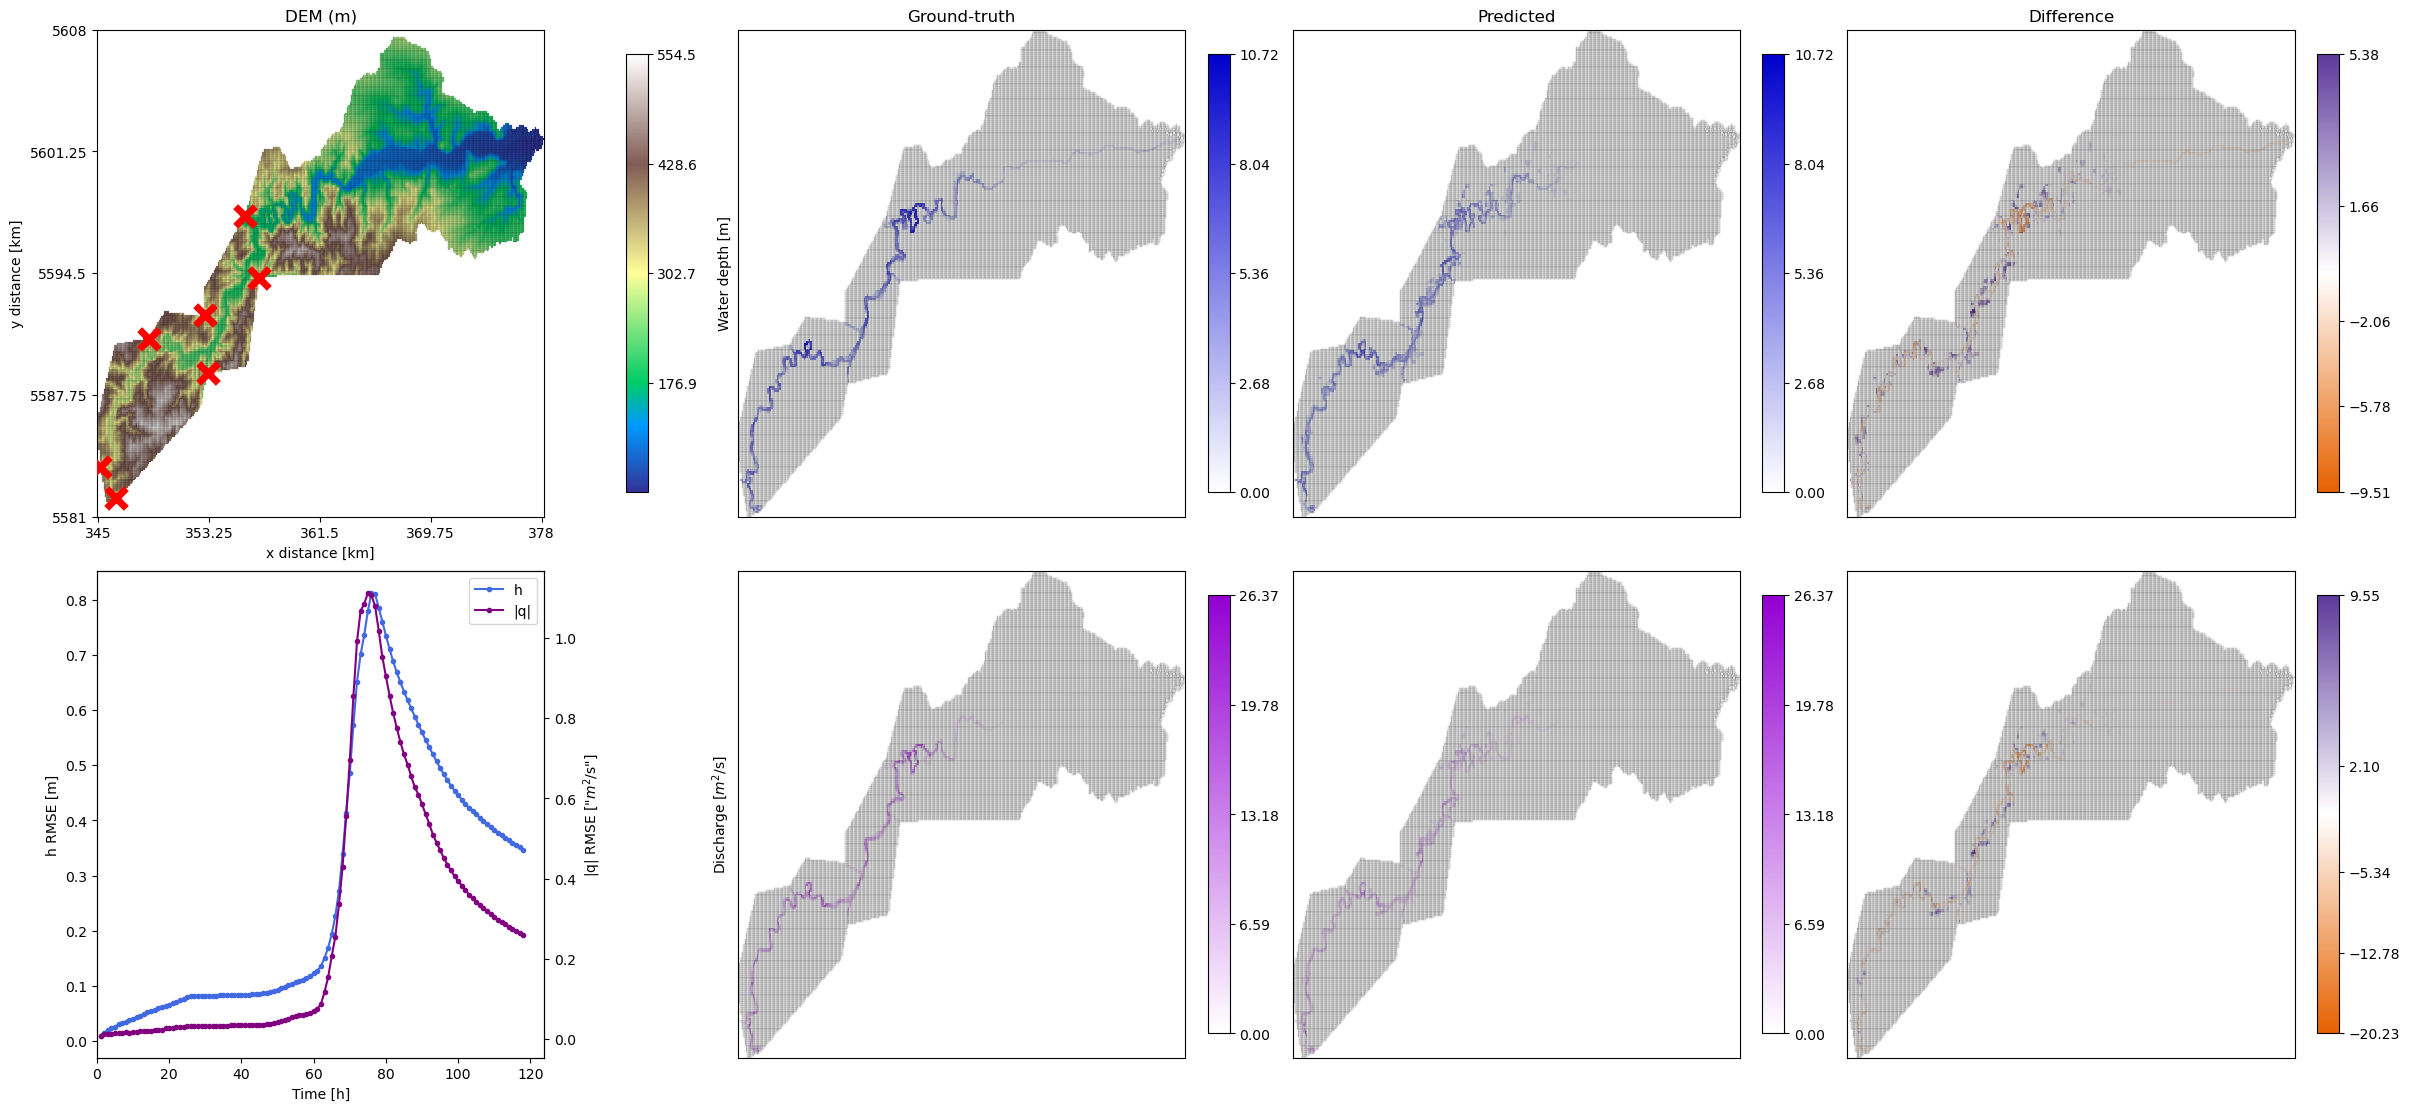

In [26]:
# Patch _reset_maxs just for this call to enforce shared scale
_orig_reset = plot_rollout._reset_maxs

def _patched_reset(*args):
    _orig_reset(*args)
    plot_rollout.real_WD.kwargs['vmax']    = plot_rollout.WD_max
    plot_rollout.predicted_WD.kwargs['vmax'] = plot_rollout.WD_max
    plot_rollout.real_V.kwargs['vmax']     = plot_rollout.V_max
    plot_rollout.predicted_V.kwargs['vmax']  = plot_rollout.V_max

plot_rollout._reset_maxs = _patched_reset

fig = plot_rollout.explore_rollout(scale=0, time_step=70)
plt.show()

plot_rollout._reset_maxs = _orig_reset  # restore original behaviour


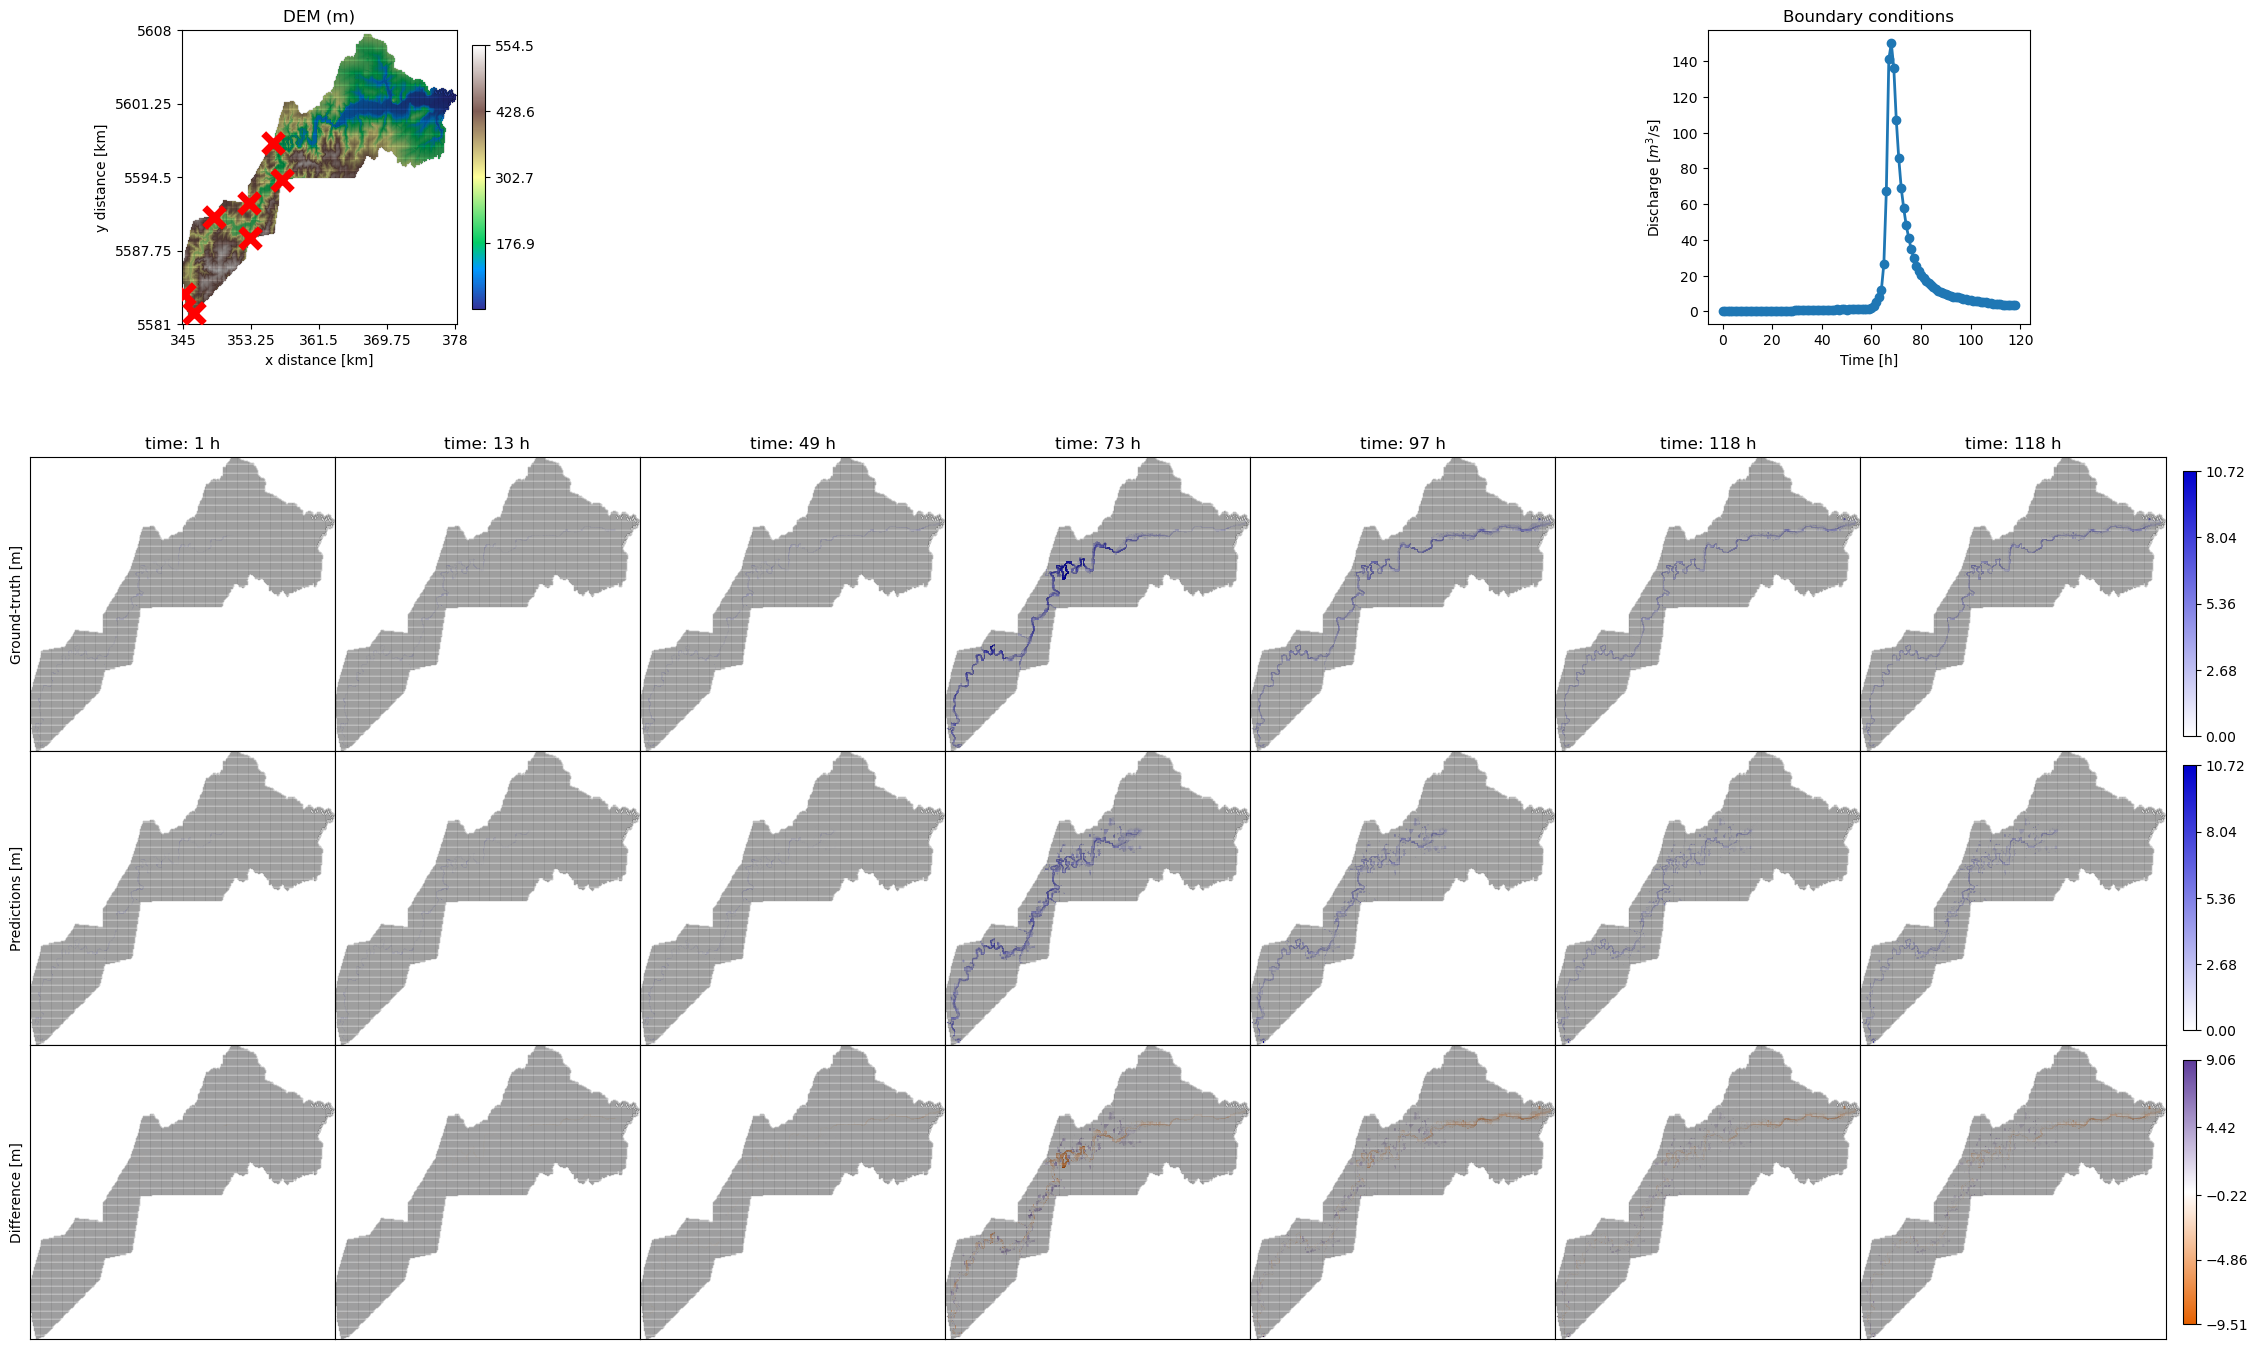

In [8]:
n_steps = plot_rollout.real_rollout.shape[-1]
plot_times = [0, 12, 48, 72, 96, n_steps - 1]
plot_rollout.compare_h_rollout(plot_times=plot_times, scale=0)
plt.show()

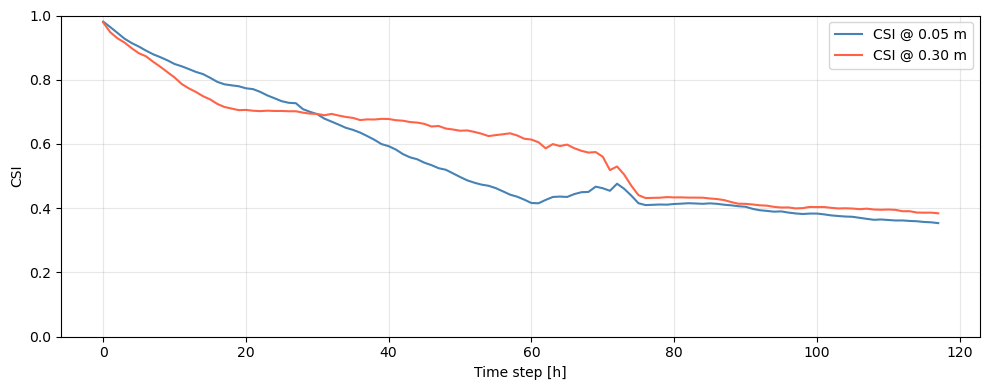

In [9]:
# CSI over time
fig, ax = plt.subplots(figsize=(10, 4))
for thr, col in [(0.05, 'steelblue'), (0.30, 'tomato')]:
    csi = plot_rollout._get_CSI(water_threshold=thr).detach().cpu().numpy()
    if csi.ndim > 1:
        csi = np.nanmean(csi, axis=0)
    ax.plot(csi, label=f'CSI @ {thr:.2f} m', color=col)
ax.set_xlabel('Time step [h]')
ax.set_ylabel('CSI')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## Metrics

In [10]:
rollout_loss = plot_rollout._get_rollout_loss(type_loss='RMSE')
loss_mean = rollout_loss.mean(0)
if loss_mean.ndim == 0:
    print(f'RMSE WD: {loss_mean.item():.4f} m')
    loss_mean = loss_mean.unsqueeze(0)
else:
    print(f'RMSE WD: {loss_mean[0].item():.4f} m')
if loss_mean.shape[0] > 1:
    print(f'RMSE V:  {loss_mean[1:].mean().item():.4f} m/s')

csi_005 = plot_rollout._get_CSI(water_threshold=0.05).nanmean().item()
csi_03  = plot_rollout._get_CSI(water_threshold=0.30).nanmean().item()
print(f'CSI @ 0.05 m: {csi_005:.4f}')
print(f'CSI @ 0.30 m: {csi_03:.4f}')

RMSE WD: 0.2617 m
CSI @ 0.05 m: 0.5474
CSI @ 0.30 m: 0.5875


## Diagnostics — loss vs CSI discrepancy
Checking whether low loss + low CSI is caused by systematic underprediction of flood extent.

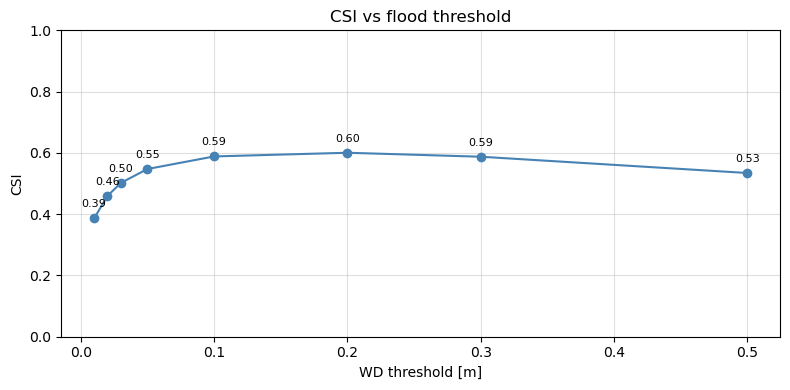

  CSI @ 0.01 m: 0.3859
  CSI @ 0.02 m: 0.4592
  CSI @ 0.03 m: 0.5018
  CSI @ 0.05 m: 0.5474
  CSI @ 0.10 m: 0.5884
  CSI @ 0.20 m: 0.6004
  CSI @ 0.30 m: 0.5875
  CSI @ 0.50 m: 0.5344


In [11]:
# CSI at multiple thresholds
thresholds = [0.01, 0.02, 0.03, 0.05, 0.10, 0.20, 0.30, 0.50]
csi_values = [plot_rollout._get_CSI(water_threshold=t).nanmean().item() for t in thresholds]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, csi_values, 'o-', color='steelblue')
ax.set_xlabel('WD threshold [m]')
ax.set_ylabel('CSI')
ax.set_title('CSI vs flood threshold')
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.4)
for t, c in zip(thresholds, csi_values):
    ax.annotate(f'{c:.2f}', (t, c), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=8)
plt.tight_layout()
plt.show()
for t, c in zip(thresholds, csi_values):
    print(f'  CSI @ {t:.2f} m: {c:.4f}')

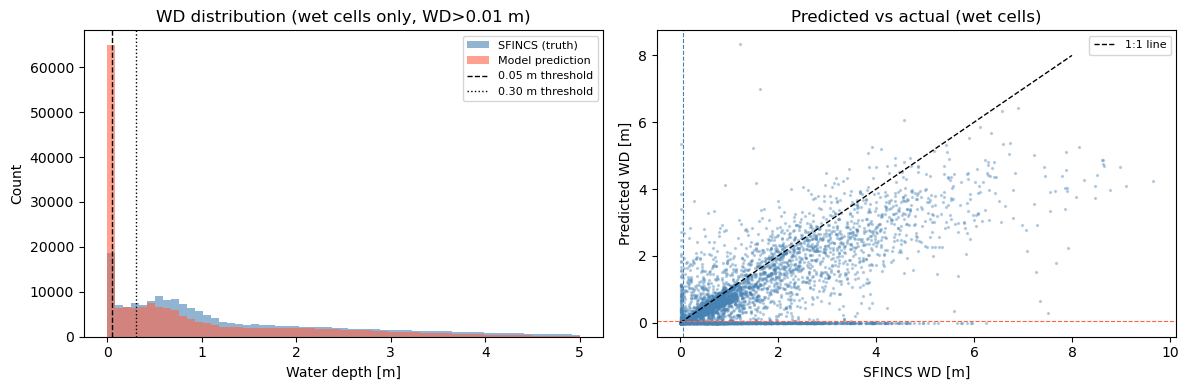


Threshold 0.05 m:
  True flooded (TP+FN):      170956
  Model catches (TP):        120255  (70.3%)
  Model misses  (FN):        50701  (29.7%)
  False alarms  (FP):        4116
  Median pred WD for true flooded: 0.515 m

Threshold 0.3 m:
  True flooded (TP+FN):      150187
  Model catches (TP):        99089  (66.0%)
  Model misses  (FN):        51098  (34.0%)
  False alarms  (FP):        6023
  Median pred WD for true flooded: 0.628 m


In [12]:
# WD histogram: predicted vs actual for wet cells
pred = plot_rollout.predicted_rollout   # [nodes, vars, T]
real = plot_rollout.real_rollout        # [nodes, vars, T]

node_ptr = test_dataset[0].node_ptr.numpy()
n0, n1 = node_ptr[0], node_ptr[1]   # finest scale

pred_WD = pred[n0:n1, 0, :].numpy().flatten()
real_WD = real[n0:n1, 0, :].numpy().flatten()

wet_mask = real_WD > 0.01
pred_wet = pred_WD[wet_mask]
real_wet = real_WD[wet_mask]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bins = np.linspace(0, min(real_wet.max(), 5), 60)
axes[0].hist(real_wet, bins=bins, alpha=0.6, label='SFINCS (truth)', color='steelblue')
axes[0].hist(pred_wet, bins=bins, alpha=0.6, label='Model prediction', color='tomato')
axes[0].axvline(0.05, color='k', linestyle='--', linewidth=1, label='0.05 m threshold')
axes[0].axvline(0.30, color='k', linestyle=':', linewidth=1, label='0.30 m threshold')
axes[0].set_xlabel('Water depth [m]')
axes[0].set_ylabel('Count')
axes[0].set_title('WD distribution (wet cells only, WD>0.01 m)')
axes[0].legend(fontsize=8)

idx = np.random.choice(len(real_wet), min(5000, len(real_wet)), replace=False)
axes[1].scatter(real_wet[idx], pred_wet[idx], s=2, alpha=0.3, color='steelblue')
lim = min(max(real_wet.max(), pred_wet.max()), 8)
axes[1].plot([0, lim], [0, lim], 'k--', linewidth=1, label='1:1 line')
axes[1].axhline(0.05, color='tomato', linestyle='--', linewidth=0.8)
axes[1].axvline(0.05, color='steelblue', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('SFINCS WD [m]')
axes[1].set_ylabel('Predicted WD [m]')
axes[1].set_title('Predicted vs actual (wet cells)')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

for thr in [0.05, 0.30]:
    tp = np.sum((real_wet > thr) & (pred_wet > thr))
    fn = np.sum((real_wet > thr) & (pred_wet <= thr))
    fp = np.sum((real_wet <= thr) & (pred_wet > thr))
    n_true = np.sum(real_wet > thr)
    print(f'\nThreshold {thr} m:')
    print(f'  True flooded (TP+FN):      {n_true}')
    print(f'  Model catches (TP):        {tp}  ({100*tp/max(n_true,1):.1f}%)')
    print(f'  Model misses  (FN):        {fn}  ({100*fn/max(n_true,1):.1f}%)')
    print(f'  False alarms  (FP):        {fp}')
    print(f'  Median pred WD for true flooded: {np.median(pred_wet[real_wet > thr]):.3f} m')

In [17]:
# Does the model improve when the flood has already started? (time_start diagnostic)
from training.train import rollout_test
from utils.dataset import to_temporal

model.eval()
print(f"{'time_start':>12}  {'n_wet_init':>12}  {'max_pred_t5':>12}  {'max_pred_t20':>12}  {'CSI@0.05':>10}")
print('-' * 65)

for ts in [0, 30, 60, 90, 120]:
    params = dict(temporal_test_dataset_parameters)
    params['time_start'] = ts
    try:
        _td = to_temporal(test_dataset[0], rollout_steps=-1, **params)[0]
    except Exception:
        print(f"{ts:>12}  skipped")
        continue

    n_wet_init = (_td.x[:, -2:].abs() > 0).any(dim=1).sum().item()

    with torch.no_grad():
        preds = rollout_test(model, _td)

    mp5  = preds[:, 0, min(5,  preds.shape[-1]-1)].max().item()
    mp20 = preds[:, 0, min(20, preds.shape[-1]-1)].max().item()

    real_td = _td.y
    T = min(preds.shape[-1], real_td.shape[-1])
    TP = ((preds[:, 0, :T] > 0.05) & (real_td[:, 0, :T] > 0.05)).sum().item()
    FP = ((preds[:, 0, :T] > 0.05) & (real_td[:, 0, :T] <= 0.05)).sum().item()
    FN = ((preds[:, 0, :T] <= 0.05) & (real_td[:, 0, :T] > 0.05)).sum().item()
    csi = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else float('nan')

    print(f"{ts:>12}  {n_wet_init:>12}  {mp5:>12.4f}  {mp20:>12.4f}  {csi:>10.4f}")

  time_start    n_wet_init   max_pred_t5  max_pred_t20    CSI@0.05
-----------------------------------------------------------------
           0          1135        1.6597        1.6452      0.3962
          30          1418        2.0751        2.0693      0.5059
          60  skipped
          90  skipped
         120  skipped


BC shape: torch.Size([7, 119])
BC (q) peak per node [m²/s]: tensor([150.0410,  66.3680, 450.0000, 126.5250, 207.1810, 209.1150, 100.4110])
edge_BC_length [m]: tensor([1., 1., 1., 1., 1., 1., 1.])

Reconstructed Q peak per node [m³/s]: tensor([150.0410,  66.3680, 450.0000, 126.5250, 207.1810, 209.1150, 100.4110])
Expected from first image: ~145 m³/s total


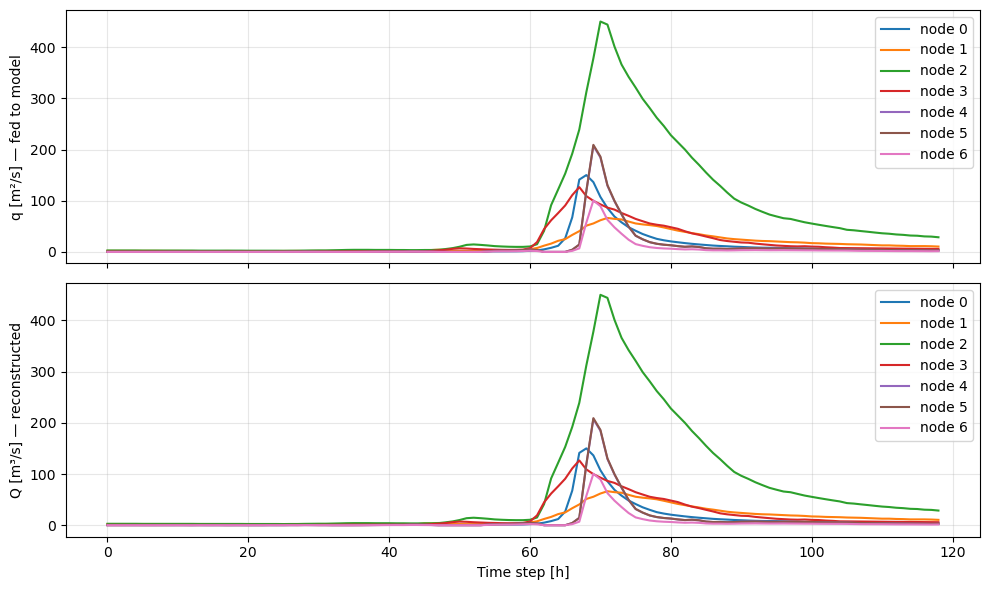

In [20]:
ds = plot_rollout.dataset

# What the model actually receives at each BC node [m²/s]
print(f"BC shape: {ds.BC.shape}")       # [num_BC_nodes, T]
print(f"BC (q) peak per node [m²/s]: {ds.BC.max(dim=1).values}")
print(f"edge_BC_length [m]: {ds.edge_BC_length}")

# Reconstruct Q [m³/s] to cross-check against the hydrograph in the first image
Q = ds.BC * ds.edge_BC_length.unsqueeze(1)
print(f"\nReconstructed Q peak per node [m³/s]: {Q.max(dim=1).values}")
print(f"Expected from first image: ~145 m³/s total")

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
for i in range(ds.BC.shape[0]):
    axes[0].plot(ds.BC[i, :].numpy(), label=f'node {i}')
    axes[1].plot(Q[i, :].numpy(), label=f'node {i}')
axes[0].set_ylabel('q [m²/s] — fed to model')
axes[1].set_ylabel('Q [m³/s] — reconstructed')
axes[1].set_xlabel('Time step [h]')
for ax in axes: ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
